# 04: Classifier Evaluation & ML Basics

*How to honestly say "this detector is good."*

This notebook is about the practical question in any hallucination-detection pipeline:

> How do we measure whether a detector is actually useful?

The answer is not just "accuracy." In real LLM evaluation, the positive class is often rare, and a model that predicts the majority class can look deceptively strong.

We cover:

- 04a. Precision, recall, F1
- 04b. ROC/AUROC vs. Precision-Recall/AUPRC
- 04c. Calibration: reliability diagrams and ECE
- 04d. Simple classifiers: logistic regression and gradient-boosted trees
- 04e. Risk-coverage / selective prediction curves

The examples below are deliberately toy, but they are designed to reflect the exact kinds of failures and tradeoffs you see in real LLM detection systems.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
)

np.random.seed(42)

print("Notebook setup complete.")
print("Random seed set to 42 for reproducibility.")

Notebook setup complete.
Random seed set to 42 for reproducibility.


## 04a. Precision, recall, F1

Accuracy is often misleading when the positive class is rare.

Suppose the true hallucination rate is around 30%. If a model simply predicts "not hallucination" for every example, it gets 70% accuracy, but it completely fails at the task we care about.

This is why we need precision, recall, and F1.

### Definitions

For a binary classifier:

- TP = true positives
- FP = false positives
- TN = true negatives
- FN = false negatives

Then:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
\text{F1} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

### Why accuracy alone is misleading

Imagine a dataset with 30% hallucinations and 70% truthful examples.

If a model predicts everything as truthful:

- accuracy = 70%
- precision = undefined or 0 if we treat no positives as zero
- recall = 0
- F1 = 0

This is a terrible detector, but accuracy alone makes it look decent.

### Worked example with a toy dataset

We create a toy dataset with 100 examples, where 30 are hallucinations and 70 are truthful.

In [2]:
# Toy dataset with 30% positive rate
n_total = 100
n_positive = 30
n_negative = 70

# Ground truth labels
true_labels = np.array([1] * n_positive + [0] * n_negative)
print("True labels:")
print(true_labels)
print("Length:", len(true_labels))
print("Positive count:", true_labels.sum())
print("Negative count:", (1 - true_labels).sum())

# A terrible classifier: predicts every case as negative
all_negative_pred = np.zeros(n_total, dtype=int)
print("\nPredictions from trivial classifier: ")
print(all_negative_pred)

# Confusion matrix
cm = confusion_matrix(true_labels, all_negative_pred)
print("\nConfusion matrix:")
print(cm)

# Metrics
acc = accuracy_score(true_labels, all_negative_pred)
prec = precision_score(true_labels, all_negative_pred, zero_division=0)
rec = recall_score(true_labels, all_negative_pred, zero_division=0)
f1 = f1_score(true_labels, all_negative_pred, zero_division=0)

print("\nAccuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

# Intuition: accuracy is high but detector is useless
print("\nTakeaway: a detector that predicts everything as negative can achieve 70% accuracy on a 30% positive dataset, but it finds zero hallucinations.")

True labels:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Length: 100
Positive count: 30
Negative count: 70

Predictions from trivial classifier: 
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Confusion matrix:
[[70  0]
 [30  0]]

Accuracy: 0.7
Precision: 0.0
Recall: 0.0
F1: 0.0

Takeaway: a detector that predicts everything as negative can achieve 70% accuracy on a 30% positive dataset, but it finds zero hallucinations.


### Better detector example

Now construct a slightly better classifier that finds some hallucinations but still makes mistakes.

In [3]:
# A better but imperfect classifier
# Predict positive for 20 of the 30 true hallucinations and 10 false positives
# Labels: 1 = hallucination, 0 = truthful

preds = np.array([1] * 20 + [0] * 10 + [1] * 10 + [0] * 60)
print("Predictions from a better detector:")
print(preds)

cm2 = confusion_matrix(true_labels, preds)
print("\nConfusion matrix:")
print(cm2)

tp = cm2[1, 1]
fp = cm2[0, 1]
fn = cm2[1, 0]
tn = cm2[0, 0]

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
acc = (tp + tn) / (tp + tn + fp + fn)

print("\nTP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Accuracy:", acc)

Predictions from a better detector:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Confusion matrix:
[[60 10]
 [10 20]]

TP: 20
FP: 10
FN: 10
TN: 60
Precision: 0.6666666666666666
Recall: 0.6666666666666666
F1: 0.6666666666666666
Accuracy: 0.8


## 04b. ROC/AUROC vs. Precision-Recall/AUPRC

The decision threshold matters.

A classifier produces scores, not just labels. If you choose a threshold, you get a confusion matrix. But if you sweep the threshold, you get a whole performance curve.

### ROC curve

The ROC curve plots:

- True Positive Rate (Recall)
- False Positive Rate

against different thresholds.

The AUROC summarizes this curve into a single number.

A perfect classifier has AUROC = 1.
A random classifier has AUROC ≈ 0.5.

### Precision-Recall curve

The PR curve plots:

- precision
- recall

against different thresholds.

This is especially useful for imbalanced datasets, because accuracy can look good even when the positive class is rare.

### Why they diverge on imbalanced data

On a dataset with many negatives and few positives, AUROC may look strong even when precision is poor. A model can have high recall with many false alarms.

This is where AUPRC is often more informative.

### Toy imbalanced dataset

We create a dataset with 1000 examples where only 100 are positive.

In [4]:
# Very imbalanced toy dataset
n_total = 1000
n_pos = 100
n_neg = 900

# Positives: scores centered higher
pos_scores = np.random.normal(loc=0.8, scale=0.15, size=n_pos)
neg_scores = np.random.normal(loc=0.4, scale=0.2, size=n_neg)

scores = np.concatenate([pos_scores, neg_scores])
labels = np.concatenate([np.ones(n_pos), np.zeros(n_neg)])

print("Positive score sample:")
print(pos_scores[:10])
print("\nNegative score sample:")
print(neg_scores[:10])
print("\nOverall score array length:", len(scores))
print("Positive label count:", labels.sum())
print("Negative label count:", (1 - labels).sum())

# ROC curve and AUROC
fpr, tpr, thresholds_roc = roc_curve(labels, scores)
auroc = roc_auc_score(labels, scores)
print("\nAUROC:", auroc)

# Precision-recall curve and AUPRC
precision, recall, thresholds_pr = precision_recall_curve(labels, scores)
auprc = average_precision_score(labels, scores)
print("AUPRC:", auprc)

# A threshold that gives perfect recall but poor precision
# This will show why ROC can be optimistic on imbalanced datasets
threshold = 0.5
preds_thresh = (scores >= threshold).astype(int)
print("\nThreshold used:", threshold)
print("Predicted positives:", preds_thresh.sum())
print("Confusion matrix at threshold 0.5:")
print(confusion_matrix(labels, preds_thresh))

p_at_05 = precision_score(labels, preds_thresh, zero_division=0)
r_at_05 = recall_score(labels, preds_thresh, zero_division=0)
f1_at_05 = f1_score(labels, preds_thresh, zero_division=0)
print("Precision @ 0.5:", p_at_05)
print("Recall @ 0.5:", r_at_05)
print("F1 @ 0.5:", f1_at_05)

print("\nTakeaway: AUROC can look good even while precision is weak in imbalanced tasks; AUPRC is often more informative.")

Positive score sample:
[0.87450712 0.77926035 0.89715328 1.02845448 0.76487699 0.76487946
 1.03688192 0.91511521 0.72957884 0.88138401]

Negative score sample:
[0.11692585 0.31587094 0.3314571  0.23954455 0.36774286 0.48081017
 0.77723718 0.43491556 0.45151008 0.38511082]

Overall score array length: 1000
Positive label count: 100.0
Negative label count: 900.0

AUROC: 0.9395777777777778
AUPRC: 0.6145119888189166

Threshold used: 0.5
Predicted positives: 381
Confusion matrix at threshold 0.5:
[[618 282]
 [  1  99]]
Precision @ 0.5: 0.25984251968503935
Recall @ 0.5: 0.99
F1 @ 0.5: 0.41164241164241167

Takeaway: AUROC can look good even while precision is weak in imbalanced tasks; AUPRC is often more informative.


### Visualizing the curves

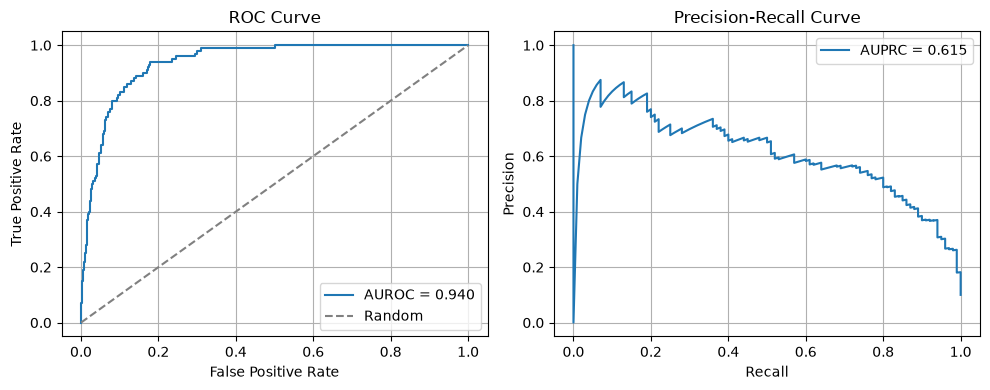

In [5]:
# ROC plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

# PR curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 04c. Calibration — reliability diagrams & ECE

A classifier is calibrated if:

> When it predicts 70% confidence, it is correct about 70% of the time.

This is distinct from discrimination quality.

A model can have high AUROC but still be poorly calibrated.

### Expected Calibration Error (ECE)

ECE approximates the average gap between confidence and accuracy across confidence bins.

$$
ECE = \sum_{b=1}^{B} \frac{|B_b|}{n} \left| \text{acc}(B_b) - \text{conf}(B_b) \right|
$$

where:

- $B_b$ is a confidence bin
- $\text{acc}(B_b)$ is empirical accuracy in that bin
- $\text{conf}(B_b)$ is average confidence in that bin

### Reliability diagram

A reliability diagram plots predicted confidence versus observed accuracy.

- perfect calibration: points lie on the diagonal
- overconfident model: points sit above the diagonal
- underconfident model: points sit below the diagonal

### Toy calibration example

We simulate predictions whose confidence is systematically too high or too low.

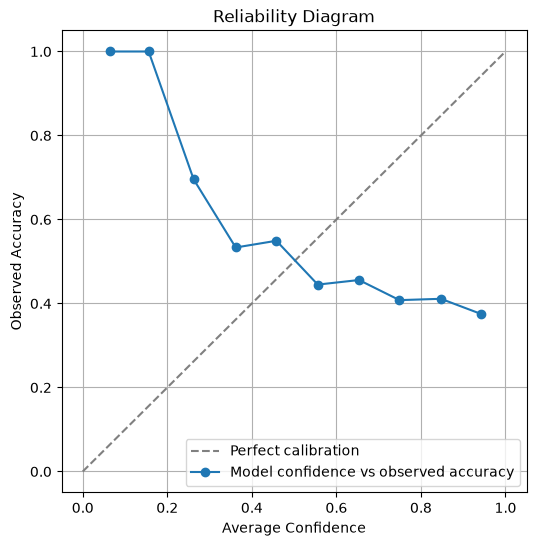

Approximate ECE: 0.33181442033471464
Average confidence: 0.7358499851661096
Average empirical correctness: 0.4288


In [6]:
# Toy calibration example
n = 5000
true = np.random.binomial(1, 0.35, size=n)

# Overconfident predictions: model says 0.9 when it is often wrong
conf_over = np.clip(np.random.normal(loc=0.75, scale=0.18, size=n), 0.05, 0.95)
# More realistic: probabilities drive outcome
# Generate outcome based on confidence
predicted_outcome = np.random.binomial(1, conf_over, size=n)

# Keep only predictions near selected confidence bins for visualization
bin_edges = np.linspace(0, 1, 11)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2
observed = []
mean_conf = []
for i in range(len(bin_edges) - 1):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    mask = (conf_over >= lo) & (conf_over < hi)
    if mask.sum() > 0:
        observed.append((predicted_outcome[mask] == true[mask]).mean())
        mean_conf.append(conf_over[mask].mean())

# A deliberately miscalibrated signal: model overpredicts confidence
# We'll visualize by plotting average confidence vs empirical accuracy
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.plot(mean_conf, observed, marker='o', label='Model confidence vs observed accuracy')
plt.title("Reliability Diagram")
plt.xlabel("Average Confidence")
plt.ylabel("Observed Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ECE on a simple example
# Binning by confidence
bins = np.linspace(0, 1, 11)
accs = []
confs = []
for i in range(len(bins) - 1):
    lo, hi = bins[i], bins[i + 1]
    mask = (conf_over >= lo) & (conf_over < hi)
    if mask.sum() > 0:
        acc = (predicted_outcome[mask] == true[mask]).mean()
        conf = conf_over[mask].mean()
        accs.append(acc)
        confs.append(conf)

# Simple ECE approximation
n = len(conf_over)
ece = sum((np.sum((conf_over >= bins[i]) & (conf_over < bins[i + 1])) / n) * abs(accs[i] - confs[i])
          for i in range(len(accs)))
print("Approximate ECE:", ece)
print("Average confidence:", conf_over.mean())
print("Average empirical correctness:", (predicted_outcome == true).mean())

## 04d. Simple classifiers — logistic regression & gradient-boosted trees

This is the practical baseline setup for a Tier-1 or Tier-2 detector.

The idea is simple:

- extract a feature vector from each sample
- train a lightweight classifier to predict hallucination risk
- evaluate with the metrics above

### Logistic regression

Logistic regression is a linear classifier.

It learns a score:

$$
z = w^T x + b
$$

and then maps it to probability:

$$
P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

This is useful when the signal is roughly linear and we want a simple, interpretable baseline.

### HistGradientBoostingClassifier

Gradient-boosted trees can capture nonlinear interactions and usually work well on tabular features.

These are often a strong baseline for: 

- model confidence features
- lexical features
- uncertainty statistics
- semantic diversity measures

### Toy ML dataset

We create a synthetic feature dataset where hallucination likelihood depends on:

- confidence score
- entropy
- token length
- repetition score

We train both a logistic model and a tree-based model.

In [7]:
# Toy tabular dataset for classifier baselines
n = 800
rng = np.random.default_rng(0)

# Features
entropy = rng.uniform(0.1, 2.5, size=n)
confidence = rng.uniform(0.1, 0.95, size=n)
length = rng.integers(20, 400, size=n)
repetition = rng.uniform(0.0, 1.0, size=n)

# Hallucination label depends on these features
logit = (
    -2.0 + 1.4 * confidence
    - 1.3 * entropy
    + 0.004 * length
    + 0.8 * repetition
)
probs = 1 / (1 + np.exp(-logit))
labels = rng.binomial(1, probs)

X = np.column_stack([entropy, confidence, length, repetition])
print("Feature matrix shape:", X.shape)
print("First 5 rows:")
print(X[:5])
print("\nLabels first 10:", labels[:10])
print("Positive rate:", labels.mean())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42, stratify=labels)
print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

# Logistic regression
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train, y_train)
logreg_proba = logreg.predict_proba(X_test)[:, 1]
logreg_pred = (logreg_proba >= 0.5).astype(int)

print("\nLogistic regression test metrics:")
print("Accuracy:", accuracy_score(y_test, logreg_pred))
print("Precision:", precision_score(y_test, logreg_pred, zero_division=0))
print("Recall:", recall_score(y_test, logreg_pred, zero_division=0))
print("F1:", f1_score(y_test, logreg_pred, zero_division=0))
print("AUROC:", roc_auc_score(y_test, logreg_proba))
print("AUPRC:", average_precision_score(y_test, logreg_proba))

# Gradient-boosted trees
xgb = HistGradientBoostingClassifier(random_state=42)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

print("\nGradient-boosted tree test metrics:")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, zero_division=0))
print("Recall:", recall_score(y_test, xgb_pred, zero_division=0))
print("F1:", f1_score(y_test, xgb_pred, zero_division=0))
print("AUROC:", roc_auc_score(y_test, xgb_proba))
print("AUPRC:", average_precision_score(y_test, xgb_proba))

Feature matrix shape: (800, 4)
First 5 rows:
[[1.62870805e+00 8.29670027e-01 1.96000000e+02 9.77281066e-01]
 [7.47488113e-01 6.27772564e-01 2.47000000e+02 6.00412576e-02]
 [1.98336457e-01 2.64830256e-01 2.89000000e+02 9.17906105e-01]
 [1.39666325e-01 6.84727343e-01 3.58000000e+02 2.79510449e-01]
 [2.05184857e+00 7.45149152e-01 2.52000000e+02 7.78871011e-02]]

Labels first 10: [0 0 1 1 1 0 0 0 0 0]
Positive rate: 0.20625

Train size: 560
Test size: 240
Train positive rate: 0.20714285714285716
Test positive rate: 0.20416666666666666

Logistic regression test metrics:
Accuracy: 0.8083333333333333
Precision: 0.5652173913043478
Recall: 0.2653061224489796
F1: 0.3611111111111111
AUROC: 0.7598033977989102
AUPRC: 0.47962651063748757

Gradient-boosted tree test metrics:
Accuracy: 0.7375
Precision: 0.3409090909090909
Recall: 0.30612244897959184
F1: 0.3225806451612903
AUROC: 0.6600064109413398
AUPRC: 0.31630997182683734


## 04e. Risk–coverage / selective prediction curves

This is the working idea behind the cascade.

Instead of forcing a decision on every example, we allow the model to abstain on the riskiest cases.

### Risk

Risk is the error rate among the samples we decide to answer.

### Coverage

Coverage is the fraction of examples the model is willing to handle.

If we reject the riskiest 20% of examples, then:

- coverage decreases
- risk often decreases
- we trade off coverage for safety

This is a direct, useful operational metric for a cascade system.

### Example

We create a score where higher score means more likely to be wrong. We then progressively reject the highest-risk examples.

Keep fraction 1.00 -> coverage = 1.000, risk = 0.270, selected_errors = 270
Keep fraction 0.90 -> coverage = 0.900, risk = 0.300, selected_errors = 270
Keep fraction 0.80 -> coverage = 0.800, risk = 0.338, selected_errors = 270
Keep fraction 0.70 -> coverage = 0.700, risk = 0.386, selected_errors = 270
Keep fraction 0.60 -> coverage = 0.600, risk = 0.425, selected_errors = 255
Keep fraction 0.50 -> coverage = 0.500, risk = 0.466, selected_errors = 233
Keep fraction 0.40 -> coverage = 0.399, risk = 0.516, selected_errors = 206
Keep fraction 0.30 -> coverage = 0.299, risk = 0.599, selected_errors = 179
Keep fraction 0.20 -> coverage = 0.200, risk = 0.730, selected_errors = 146


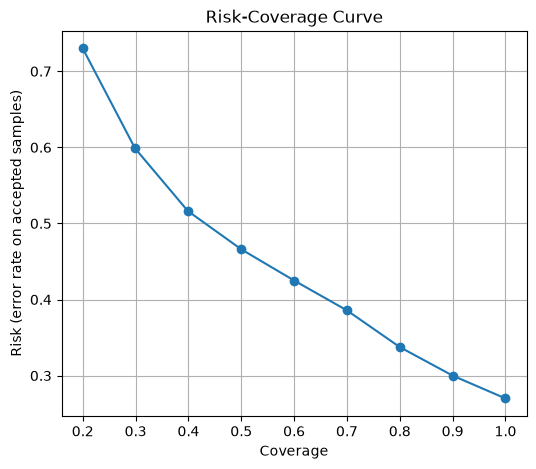


Interpretation: as coverage decreases, the accepted examples become safer, which is useful for abstention-based cascades.


In [8]:
# Risk-coverage simulation
n = 1000
rng = np.random.default_rng(1)

# Ground truth label: 1 means hallucination/error
true = rng.binomial(1, 0.25, size=n)

# Risk score: higher risk means more likely to be wrong
risk_score = rng.uniform(0, 1, size=n)
# Make the score correlated with actual error
risk_score = np.clip(risk_score + 0.5 * true, 0, 1)

# Sort by risk descending and evaluate coverage/risk tradeoff
order = np.argsort(risk_score)[::-1]
true_sorted = true[order]
score_sorted = risk_score[order]

coverage = []
risk = []

for keep_frac in np.linspace(1.0, 0.2, 9):
    k = int(len(true_sorted) * keep_frac)
    selected = true_sorted[:k]
    coverage_val = k / len(true_sorted)
    risk_val = selected.mean() if len(selected) > 0 else 0.0
    coverage.append(coverage_val)
    risk.append(risk_val)
    print(f"Keep fraction {keep_frac:.2f} -> coverage = {coverage_val:.3f}, risk = {risk_val:.3f}, selected_errors = {selected.sum()}")

plt.figure(figsize=(6, 5))
plt.plot(coverage, risk, marker='o')
plt.title("Risk-Coverage Curve")
plt.xlabel("Coverage")
plt.ylabel("Risk (error rate on accepted samples)")
plt.grid(True)
plt.show()

print("\nInterpretation: as coverage decreases, the accepted examples become safer, which is useful for abstention-based cascades.")

## Summary

This notebook focuses on the honest evaluation of a detector:

- accuracy alone is not enough when the positive class is rare
- precision, recall, and F1 tell us whether we are catching the actual failures we care about
- ROC/AUROC is useful for ranking, but PR/AUPRC is often more informative on imbalanced data
- calibration asks whether the model's confidence actually matches reality
- simple logistic or tree models are strong practical baselines
- risk-coverage analysis is exactly the right way to think about abstention in a cascade system

This is the operating language for the downstream project: if the detector is not precise enough, not calibrated, or not selective enough, the final decision system will not be trustworthy.